# 08 Explainability

UCI Bank Marketing Dataset — building on notebook 07's final evaluation. Input: `data/processed/bank_marketing_features.csv`.

This notebook asks *why* the final model predicts what it predicts — it does not retrain, retune, re-select a threshold, or change the feature set. The model, the feature policy (`duration` excluded), and the operating threshold (0.15) are exactly what notebooks 06 and 07 already established. The test set is used here only to generate explanations, never to change the model.

## 1. Load Final Model / Reproduce Final Model

**Final model (from notebooks 06-07): Logistic Regression, `C=1`, `class_weight=None`.** No serialized model file exists yet (that's a later phase), so this notebook reproduces the exact same fitted pipeline by refitting with the same hyperparameters, the same `random_state`, and the same training data — deterministic, not a new modeling decision.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_columns', None)

BLUE = '#2a78d6'
ORANGE = '#eb6834'

df = pd.read_csv('../data/processed/bank_marketing_features.csv')
df.shape

(41176, 25)

## 2. Load Evaluation Data

Same feature policy, same chronological split, same preprocessing as notebooks 05-07.

In [2]:
before_call_features = [col for col in df.columns if col not in ['y', 'duration']]
y = (df['y'] == 'yes').astype(int)
X = df[before_call_features]

train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

numeric_features = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                     'cons.conf.idx', 'euribor3m', 'nr.employed',
                     'contacts_before_this_call', 'was_previously_contacted']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
                         'month', 'day_of_week', 'poutcome', 'age_group', 'education_grouped']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1, class_weight=None, max_iter=1000, random_state=42))
])
final_pipeline.fit(X_train, y_train)

/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'contacts_before_this_call',
                                                   'was_previously_contacted']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'age_group',
                                                   'education_grouped'])])),
                ('classifier',
                 LogisticRegression(C=1, max_iter=1000, random_state=42))])

The test set is used from here on, but only to compute explanations of predictions the model already made — not to relabel, retrain, or reselect anything.

## 3. Final Model Overview

Quick recap of what's being explained, carried over from notebook 07 rather than recomputed:

| | |
|---|---|
| Model | Logistic Regression |
| Hyperparameters | `C=1`, `class_weight=None` |
| Operating threshold | 0.15 |
| Test ROC-AUC | 0.747 |
| Test PR-AUC | 0.534 |
| Test Recall @ 0.15 | 0.793 |
| Test Precision @ 0.15 | 0.456 |

This notebook does not re-derive these numbers — see notebook 07 for the full evaluation.

## 4. Global Feature Importance

Logistic Regression is linear, so its coefficients already give an exact, transparent global explanation — no approximation needed. Each coefficient is the effect of a one-unit change in that (scaled) feature on the model's **log-odds** output, holding every other feature fixed.

In [3]:
feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
clean_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

print(f'{len(clean_names)} features after preprocessing')
print('duration present:', any('duration' in name for name in clean_names))

75 features after preprocessing
duration present: False


`duration` is confirmed absent — the first of this notebook's sanity checks (Section 8 does the rest).

In [4]:
coefficients = final_pipeline.named_steps['classifier'].coef_[0]
coef_table = pd.DataFrame({'feature': clean_names, 'coefficient': coefficients})
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
top_coefficients = coef_table.sort_values('abs_coefficient', ascending=False).head(15)
top_coefficients.drop(columns='abs_coefficient')

,feature,coefficient
53,month_oct,1.702531
59,poutcome_failure,-1.087055
61,poutcome_success,1.039983
52,month_nov,-1.002253
3,emp.var.rate,-0.940457
51,month_may,-0.918898
6,euribor3m,0.857393
50,month_mar,0.708959
49,month_jun,-0.493081
60,poutcome_nonexistent,-0.436556


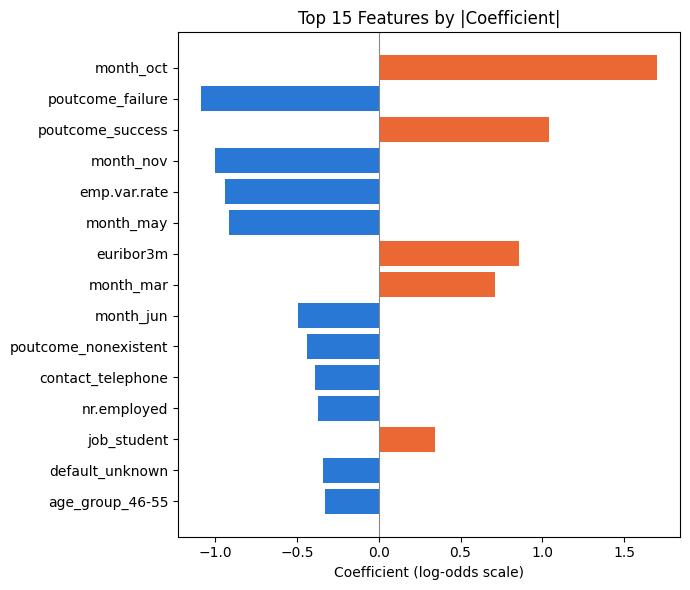

In [5]:
colors = [ORANGE if c > 0 else BLUE for c in top_coefficients['coefficient']]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_coefficients['feature'], top_coefficients['coefficient'], color=colors)
ax.axvline(0, color='#898781', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Coefficient (log-odds scale)')
ax.set_title('Top 15 Features by |Coefficient|')
plt.tight_layout()
plt.show()

Orange bars push the prediction toward **yes** (positive coefficient); blue bars push it toward **no** (negative coefficient) — the same color convention used for the target throughout this project.

**A quick odds-ratio reading, since this is a linear model:** exponentiating a coefficient gives a multiplicative effect on the odds of subscribing. `poutcome_success` has a coefficient of about 1.04, so `exp(1.04) ≈ 2.8` — being in the `success` category is associated with roughly 2.8x the odds of subscribing compared to the reference category, holding everything else in the model fixed. That's a statement about this model's learned association, not a claim that a successful prior campaign *causes* the next one to succeed.

**Feature importance is not causation.** These coefficients describe how the trained model uses each feature to produce a prediction, not what actually drives a customer's decision to subscribe. Confounding, multicollinearity, and the historical nature of this data (Section 8 revisits this) all mean the coefficients should be read as *model behavior*, not *real-world cause and effect*.

## 5. SHAP Global Explanation

**What SHAP is.** SHAP (SHapley Additive exPlanations) borrows an idea from cooperative game theory: given a prediction, it fairly splits the credit for that prediction among the input features. For any single prediction, the SHAP values of every feature add up exactly to (prediction - average prediction) — so they aren't just a rough importance score, they reconstruct the actual prediction.

**What a SHAP value represents.** For one feature, on one prediction, its SHAP value is how much that feature's value pushed *that specific prediction* away from the model's average prediction. A **positive** SHAP value pushes the prediction toward `yes`; a **negative** one pushes it toward `no`.

**Global vs. local.** A *local* explanation is the SHAP values for one prediction (Section 7). A *global* explanation, here, is built by looking at SHAP values across many predictions at once — e.g. the average absolute SHAP value per feature, which ranks features by how much they typically move predictions.

**Why `LinearExplainer`.** SHAP has several explainer types, chosen by model type. Since the final model is linear, `shap.LinearExplainer` computes *exact* SHAP values directly from the model's coefficients — fast, with no approximation. Tree models need `TreeExplainer`; arbitrary black-box models need the much slower, approximate `KernelExplainer`. Using the simplest explainer that's exact for this model type is the right choice here, not a more complex one.

One technical detail worth stating plainly: because Logistic Regression's raw output is log-odds (before the sigmoid turns it into a probability), the SHAP values below are also in log-odds units, same as the coefficients in Section 4. Section 7 shows how to convert a total SHAP contribution back into a probability.

In [6]:
X_train_transformed = final_pipeline.named_steps['preprocessor'].transform(X_train)
X_test_transformed = final_pipeline.named_steps['preprocessor'].transform(X_test)

# a small random background sample stands in for "the average customer" that SHAP compares against
background = shap.sample(X_train_transformed, 100, random_state=42)
explainer = shap.LinearExplainer(final_pipeline.named_steps['classifier'], background)

In [7]:
sample_idx = np.random.RandomState(42).choice(len(X_test_transformed), 500, replace=False)
X_test_sample = X_test_transformed[sample_idx]

shap_values = explainer(X_test_sample)
shap_values.feature_names = clean_names
shap_values.values.shape

(500, 75)

500 test rows are sampled purely to keep the plots readable and fast to compute — this does not touch `y_test` anywhere, only the feature values `X_test` the model already generated predictions from in notebook 07.

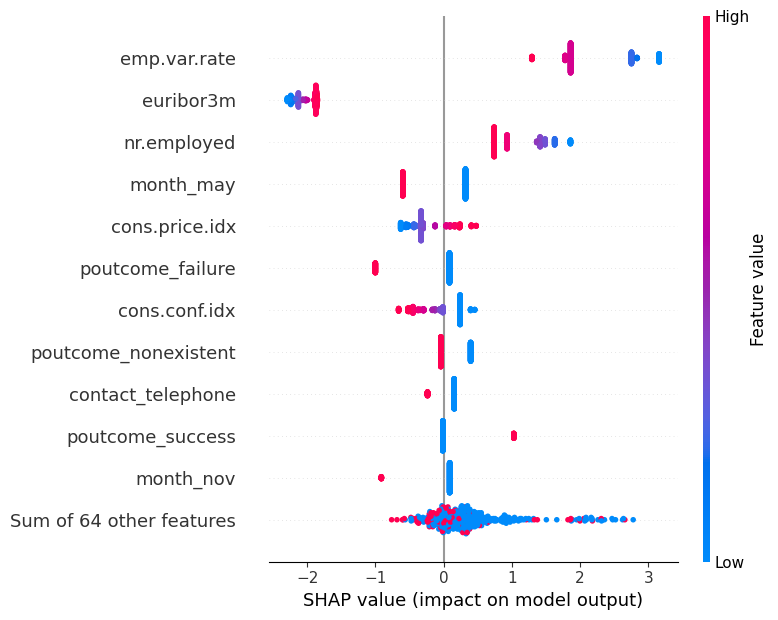

In [8]:
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.show()

Each dot is one customer. Position left-to-right is that feature's SHAP value for that customer (its pull toward `no` or `yes`); color is whether that customer's actual feature value was high (pink) or low (blue).

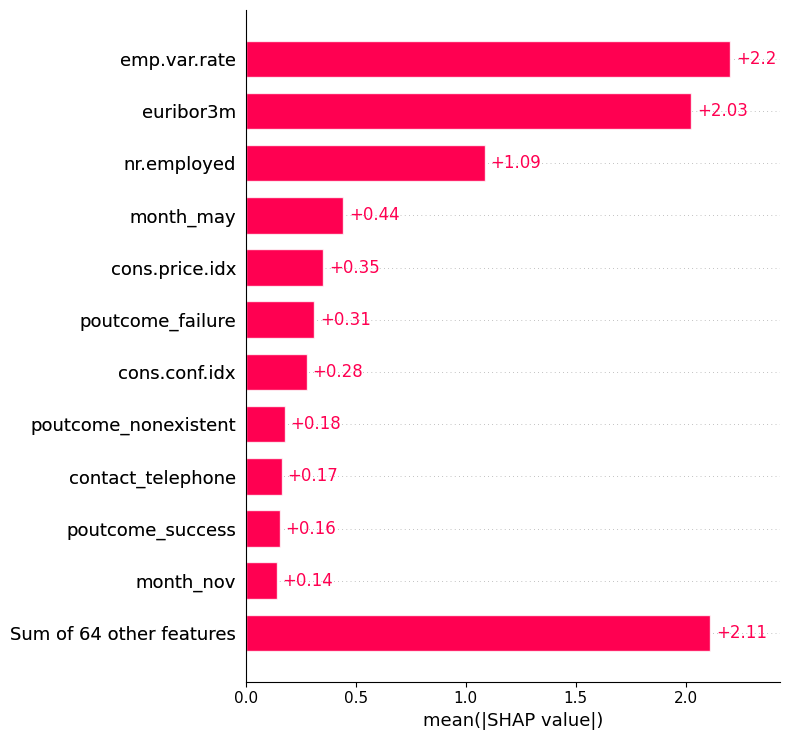

In [9]:
shap.plots.bar(shap_values, max_display=12, show=False)
plt.tight_layout()
plt.show()

This ranks features by mean absolute SHAP value — the average size of their pull on a prediction, in either direction. It's worth comparing this ranking to Section 4's coefficient ranking: they don't match exactly. `month_oct` has one of the largest raw coefficients, but it barely registers here, because SHAP importance reflects the coefficient *combined with* how often and how strongly that feature actually varies in the data — October is a rare month, so its large per-unit effect rarely gets used. `emp.var.rate`, `euribor3m`, and `nr.employed`, by contrast, are continuous and vary for every customer, so their influence accumulates broadly across the whole dataset. This is a good illustration of why coefficient size and SHAP importance answer slightly different questions — one is the effect *per unit*, the other is the effect *actually observed in the data*.

## 6. Direction of Feature Contributions

For a linear model, the coefficient sign is the exact, unambiguous source of truth for direction — the beeswarm plot above visually confirms it, but the coefficient table already states it precisely:

- **`poutcome_success` (+1.04)**, **`job_student` (+0.34)**, **`month_oct` (+1.70)** — these feature values are associated with a *higher* predicted subscription probability.
- **`poutcome_failure` (-1.09)**, **`month_may` (-0.92)**, **`contact_telephone` (-0.39)**, **`default_unknown` (-0.34)** — these are associated with a *lower* predicted probability.
- **`emp.var.rate` (-0.94)** and **`nr.employed` (-0.37)** — higher values of these economic indicators are associated with *lower* predicted probability.

All of these line up with the raw patterns already found in notebook 02's EDA (e.g. `student`/`retired` jobs, `poutcome == 'success'`, and `month == 'may'` having the most extreme subscription rates there too) — a reassuring sign that the model learned genuine, explainable patterns rather than something arbitrary.

**One feature does not line up, and it's worth flagging rather than glossing over: `euribor3m` has a *positive* coefficient (+0.86) here, meaning higher `euribor3m` pushes predictions toward `yes` in this model** — but notebook 02's raw EDA found `euribor3m` *negatively* correlated with the target (-0.31: higher `euribor3m` went with *lower* subscription rates overall). This isn't a bug. Notebook 02 also found `emp.var.rate`, `euribor3m`, `cons.price.idx`, and `nr.employed` strongly inter-correlated (0.69-0.97) — classic multicollinearity. When predictors move together this strongly, a linear model's individual coefficients can become unstable or even flip sign, because "holding the other correlated variables constant" is a shaky idea when they rarely vary independently in the data. **`euribor3m`'s coefficient here should be read as a modeling artifact of multicollinearity, not a reliable standalone effect** — exactly the kind of surprising pattern this notebook is meant to surface.

## 7. Individual Prediction Explanations

Three test customers, chosen to represent a high, a medium (right at the operating threshold), and a low predicted probability. Only the handful of feature values that actually matter for each explanation are shown, not the full customer record.

In [10]:
test_probs = final_pipeline.predict_proba(X_test)[:, 1]
probs_series = pd.Series(test_probs, index=X_test.index)

chosen_threshold = 0.15

high_idx = probs_series.idxmax()
low_idx = probs_series.idxmin()
medium_idx = (probs_series - chosen_threshold).abs().idxmin()

examples = [('High probability', high_idx), ('Medium (near the threshold)', medium_idx), ('Low probability', low_idx)]

/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [11]:
for label, idx in examples:
    position = X_test.index.get_loc(idx)
    probability = test_probs[position]
    prediction = 'YES' if probability >= chosen_threshold else 'NO'

    print(f'--- {label} ---')
    print(f'Probability = {probability:.4f}')
    print(f'Threshold   = {chosen_threshold}')
    print(f'Prediction  = {prediction}')
    print(X_test.loc[idx, ['job', 'age_group', 'month', 'poutcome', 'previous', 'euribor3m', 'emp.var.rate']])
    print()

--- High probability ---
Probability = 0.9872
Threshold   = 0.15
Prediction  = YES
job             student
age_group         18-25
month               oct
poutcome        success
previous              4
euribor3m         0.982
emp.var.rate       -1.1
Name: 40917, dtype: object

--- Medium (near the threshold) ---
Probability = 0.1499
Threshold   = 0.15
Prediction  = NO
job             technician
age_group            56-65
month                  jun
poutcome           failure
previous                 1
euribor3m            0.742
emp.var.rate          -1.7
Name: 39910, dtype: object

--- Low probability ---
Probability = 0.0198
Threshold   = 0.15
Prediction  = NO
job             blue-collar
age_group             46-55
month                   may
poutcome            failure
previous                  1
euribor3m              1.25
emp.var.rate           -1.8
Name: 34939, dtype: object



The probability is a continuous estimate of subscription likelihood; the threshold is a separate, deliberately-chosen business decision (notebook 07) about which probabilities are worth acting on. The medium example above sits almost exactly on that line — a reminder that a small change in probability right at the threshold can flip the final decision, even though the model's underlying estimate barely changed at all.

Now the local SHAP explanation for each of the three — which features pushed each prediction where.

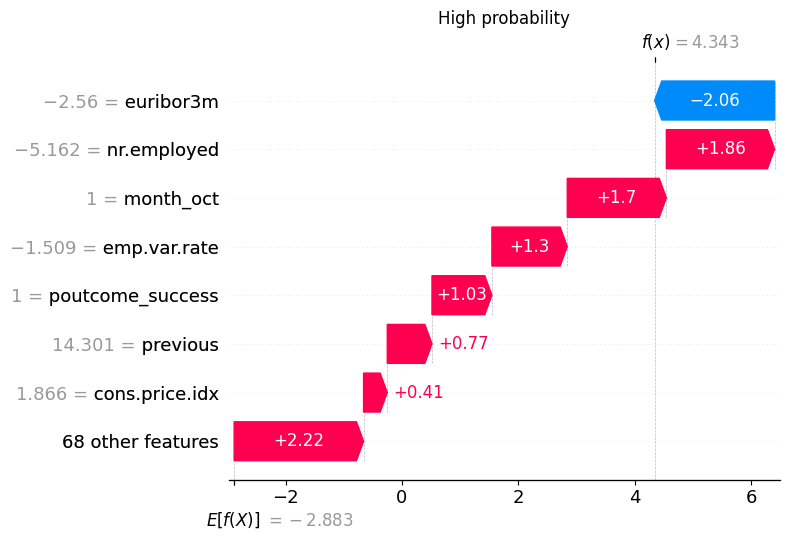

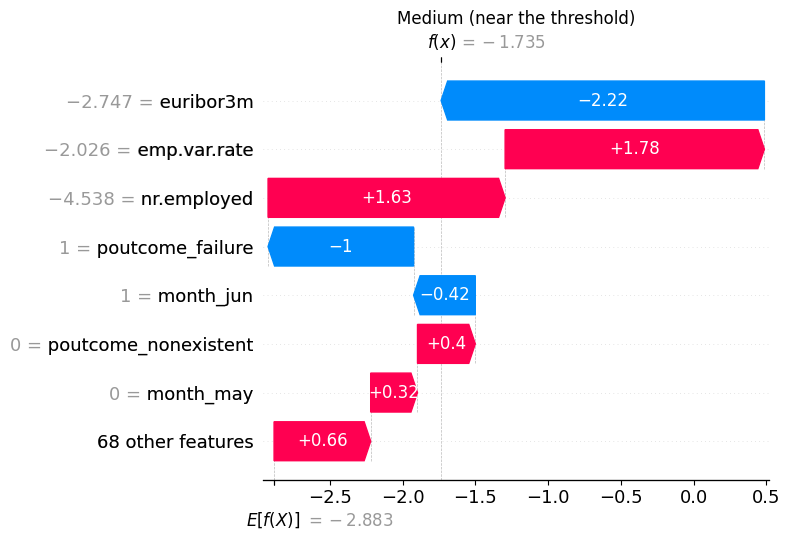

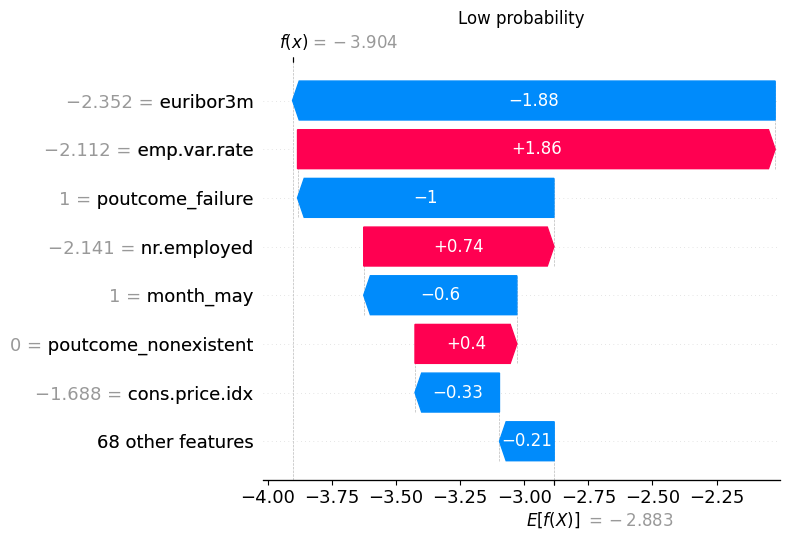

In [12]:
for label, idx in examples:
    position = X_test.index.get_loc(idx)
    row_transformed = X_test_transformed[position:position + 1]
    row_shap = explainer(row_transformed)
    row_shap.feature_names = clean_names

    shap.plots.waterfall(row_shap[0], max_display=8, show=False)
    plt.title(label)
    plt.tight_layout()
    plt.show()

## 8. Explainability Sanity Checks

- **Does `duration` appear anywhere?** No — confirmed explicitly in Section 4, and it was never in `before_call_features` to begin with (notebook 03).
- **Are the most influential features plausible?** Mostly yes. `poutcome`, `month`, `contact` type, `job`, and `default` status all have sensible, EDA-consistent directions (Section 6). The economic indicators being highly influential also makes sense — they were the strongest raw correlates with the target back in notebook 02.
- **Any unexpected features dominating?** The three macroeconomic indicators (`emp.var.rate`, `euribor3m`, `nr.employed`) dominate the SHAP ranking more than any customer-specific attribute. That means this model leans more heavily on **when** a contact happens than **who** the customer is — worth remembering given notebooks 05-07 already found this dataset has a real shift in behavior over time. A model leaning on time-varying signals is more exposed to that kind of drift than one leaning on stable customer traits.
- **Any suspicious features?** `euribor3m`'s sign flip relative to its raw EDA correlation (Section 6) is the one genuinely suspicious pattern found — traced to multicollinearity among the economic indicators, not a data leak or a coding error. It's a limitation of this specific linear model's coefficients, not of the explanation method.
- **Any leakage into the explanation itself?** No test labels (`y_test`) were used anywhere in this notebook — every SHAP value and every plot is a function of `X_test` and the already-trained model only.

## Explainability Summary

1. **Most influential features**: `emp.var.rate`, `euribor3m`, and `nr.employed` (the macroeconomic indicators) lead by average SHAP impact, followed by `month` (particularly `may`), `poutcome`, and `contact` type.
2. **Direction**: `poutcome_success`, `job_student`, and `month_oct` push predictions toward `yes`; `poutcome_failure`, `month_may`, `contact_telephone`, `default_unknown`, and higher `emp.var.rate`/`nr.employed` push toward `no`. All of these are consistent with notebook 02's EDA.
3. **Examples shown**: a high-probability customer (student, contacted in October, prior campaign success), a customer sitting almost exactly on the 0.15 threshold, and a low-probability customer (blue-collar, contacted in May, prior campaign failure) — each with a full SHAP breakdown of what drove that specific prediction.
4. **Important observation**: the model relies more on macroeconomic, time-varying signals than on customer-specific traits — consistent with, and a partial explanation for, the train/test performance differences documented in notebooks 05-07.
5. **Surprising/concerning pattern**: `euribor3m` has a positive coefficient in the model despite a negative raw correlation with the target in EDA — a multicollinearity artifact among the four highly inter-correlated economic indicators, not a reliable independent effect. This is a real limitation of interpreting individual coefficients from this specific linear model, disclosed rather than hidden.
6. **`duration` confirmation**: `duration` does not appear anywhere in the feature set, the coefficients, or the SHAP values — confirmed directly in Section 4 and again in Section 8.
7. **Feature importance is not causation.** Everything in this notebook explains *how the trained model arrived at its predictions* — which learned associations it relies on and how strongly. None of it establishes that any feature actually *causes* a customer to subscribe, and the `euribor3m` finding above is a concrete example of why that distinction matters: a model can lean on a variable for reasons that have more to do with its correlation with other variables than with any real-world mechanism.